In [1]:
#packages
import requests
import pandas as pd
import json
from glob import glob
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px

import geopandas as gpd

# STEP A — PCA on socioeconomic variables (tract-level)

Procedure:

    • Standardize variables
    • Run PCA
    • Keep PC1–PC3 (likely ≥60–80% variance)
    • Extract tract-level PCA scores

Figures:

    • Scree plot
    • Loading plot (which variables drive each PC)
    • Table of PCA scores by tract

In [2]:
#pulling standardized socioeconomic variables
tract_socioeconomic = pd.read_csv('data_processed/PCA_data/tract_socioeconomic.csv')
tract_socioeconomic['TRACT'] = tract_socioeconomic['TRACT'].astype(str).str.zfill(6)

In [3]:
#Dropping the tracts with NAs
tract_socioeconomic_clean = tract_socioeconomic.dropna()

#Keeping derived calculations only
ses_vars = [
    "median_household_income",
    "pct_below_50pct_poverty",
    "pct_no_vehicle",
    "pct_renters_cost_burdened",
    "pct_over65",
    "pct_with_disability",
    "pct_nonwhite"
]

In [4]:
# Separate features and ID
X = tract_socioeconomic_clean.drop(columns=['TRACT'])  
X = X[ses_vars] 
tract_ids = tract_socioeconomic_clean['TRACT']      


Keeping only Durham, Wake, and Orange County (located in the RTP)

In [5]:
# RTP county FIPS codes
rtp_counties = ['119']  # Mecklenburg

# Ensure TRACT is a string
tract_socioeconomic_clean['TRACT'] = tract_socioeconomic_clean['TRACT'].astype(str)

# Extract county FIPS (digits 3–5)
tract_socioeconomic_clean['county_fips'] = tract_socioeconomic_clean['TRACT'].str[2:5]

# Keep only RTP counties
tract_socioeconomic_clean = tract_socioeconomic_clean[
    tract_socioeconomic_clean['county_fips'].isin(rtp_counties)
].copy()

# Separate features and IDs
X = tract_socioeconomic_clean.drop(columns=['TRACT', 'county_fips'])
X = X[ses_vars]
tract_ids = tract_socioeconomic_clean['TRACT']

/var/folders/x4/39bns7ns63g9446c_4gzy_tr0000gn/T/ipykernel_80581/308894734.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tract_socioeconomic_clean['TRACT'] = tract_socioeconomic_clean['TRACT'].astype(str)
/var/folders/x4/39bns7ns63g9446c_4gzy_tr0000gn/T/ipykernel_80581/308894734.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tract_socioeconomic_clean['county_fips'] = tract_socioeconomic_clean['TRACT'].str[2:5]


## Scree Plot

To see how many PCs to keep

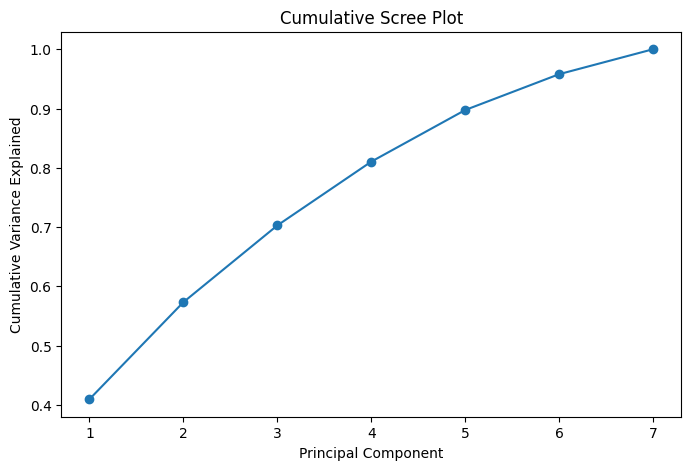

In [6]:
pca = PCA(n_components=7)
pca_scores = pca.fit_transform(X)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(),
         marker='o')

plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.title("Cumulative Scree Plot")
plt.show()

PC1: ~42%

PC2: ~61% cumulative

PC3: ~74% cumulative

PC4: ~84% cumulative

PC5: ~91% cumulative

There’s a clear elbow around PC3–PC4.

## Running PCA for 3 components

In [7]:
# Keeping first three principle components
pca = PCA(n_components=3)
pca_scores = pca.fit_transform(X)

In [8]:
# Turn PCA scores into a dataframe
socioeconomic_tract_pca_scores = pd.DataFrame(
    pca_scores,
    columns=['PC1', 'PC2', 'PC3']
)
socioeconomic_tract_pca_scores['TRACT'] = tract_ids.values   # add back id

# Get PCA loadings
socioeconomic_tract_loadings = pd.DataFrame(
    pca.components_.T,     # each row = variable, each column = PC
    index=X.columns,
    columns=['PC1', 'PC2', 'PC3']
)



PCA transforms correlated socioeconomic variables into a smaller number of independent components PC1, PC2, PC3.

tract_socioeconomic_pca: Displays tract-level PCA scores

PCA Scores: where does each tract lie along these abstract socioeconomic axes

Loadings: which variables define each principal component (ie which pattern does PC1, PC2, and PC3 represent). The are weights linking original variables to each principal component.

In [9]:
socioeconomic_tract_loadings.to_csv('data_processed/socioeconomic_pca_results_Charlotte/socioeconomics pca loadings.csv', index=True)

## Loadings Interpretation:

### PC1

Income Disparity & Racial Composition

Higher tracts: higher incomes, people are not in poverty, these are very white, able bodied, some are slightly older, 

Low tracts: lower incomes, people in poverty, colored folks, slightly more disabled

### PC2

Disability 

Higher: middle class, but there is high disability here, and more folks who are non white, they are renters cost burdened, so thinking like young folks who are disabled and not necessarily rich, no vehicles, so esp people who live in the heart of the city

Lower: 

### PC3

Transportation Access vs Age

high: These are people who don't have access to a vehicle, but are very renters cost burdened and older, so thinking these are older folks who live in more densley populated parts of the city

low: 

# STEP B — Cluster census tracts using PCA scores

Use k-means or hierarchical clustering.

Your advisor wants:

    • Cluster tracts based on PC1, PC2, PC3 scores
    • THEN examine outage metrics within each cluster

Output per cluster:

    • Socioeconomic profile (low-income, old housing, rural, etc.)
    • Average outage frequency
    • Average outage duration
    • Weather exposure metrics
    
This gives us: which types of communities experience which outages?

## Choose k (number of clusters)
Via:
- elbow method
- silhouette score

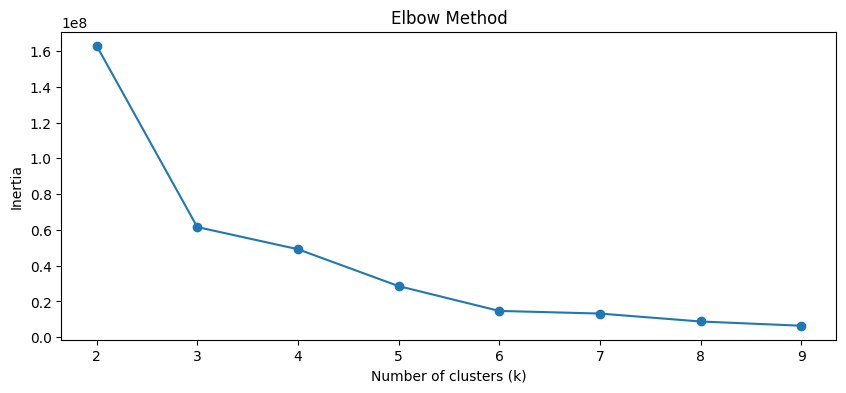

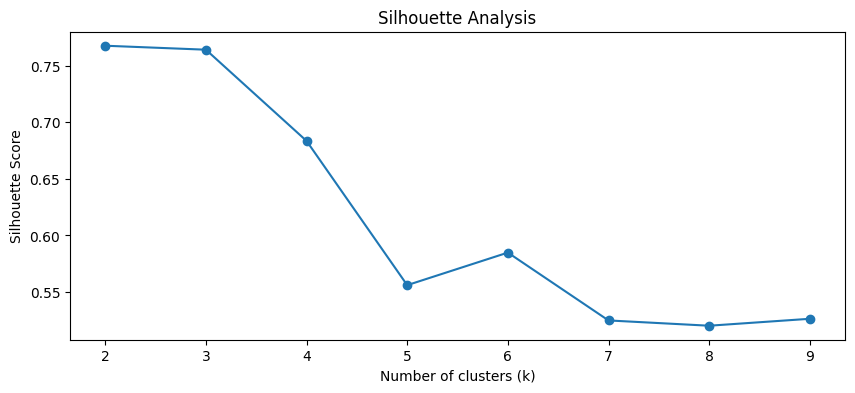

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

Ks = range(2, 10)
inertias = []
silhouettes = []

for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(socioeconomic_tract_pca_scores)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(socioeconomic_tract_pca_scores, labels))

# Plot elbow
plt.figure(figsize=(10,4))
plt.plot(Ks, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Plot silhouette
plt.figure(figsize=(10,4))
plt.plot(Ks, silhouettes, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

Choosing k = 3

## Run clustering (k-means / hierarchical)

In [11]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42)
socioeconomic_tract_pca_scores['cluster'] = kmeans.fit_predict(socioeconomic_tract_pca_scores)

## Characterize each cluster

Using the unscaled, real socioeconomic variables.

In [12]:
#pulling unscaled socioeconomic variables
tract_socioeconomic_unscaled = pd.read_csv('data_processed/PCA_data/tract_socioeconomic_unscaled.csv')
tract_socioeconomic_unscaled['TRACT'] = tract_socioeconomic_unscaled['TRACT'].astype(str).str.zfill(6)

df = tract_socioeconomic_unscaled.merge(socioeconomic_tract_pca_scores[['TRACT','cluster']], on='TRACT')

socioeconomic_cluster_profiles = df.groupby('cluster')[ses_vars].mean()


It does not seem like NC census tracts fall into sharply distinct socioeconomic groups with these socioeconomic variables. So I instead want to identify SES outliers with PCA Distance. These would be socioeconomic "extreme" tracts.

## Identify standout tracts directly using PCA scores and distances

### Identify SES Outliers Using PCA Distance

In [13]:
pc_df = socioeconomic_tract_pca_scores[['PC1','PC2','PC3']].copy()
pc_df['TRACT'] = socioeconomic_tract_pca_scores['TRACT']

pc_df['distance'] = np.sqrt(pc_df['PC1']**2 + pc_df['PC2']**2 + pc_df['PC3']**2)

#Identifying 20 "outliers"
pc_df.nlargest(20, 'distance')


,PC1,PC2,PC3,TRACT,distance
81,4.194720,2.724614,2.317843,37119003020,5.512857
65,4.982672,1.750243,0.483812,37119002800,5.303249
124,-2.456236,-2.706809,3.490501,37119004800,5.054059
64,4.531622,2.086146,-0.314139,37119002702,4.998629
210,3.168767,2.909872,2.337058,37119005846,4.895946
59,-4.434060,2.004624,-0.053489,37119002300,4.866443
110,-4.396148,1.887839,0.140623,37119003903,4.786422
63,4.724319,0.500494,0.368845,37119002701,4.765053
294,4.112372,1.323467,-1.625162,37119006404,4.615660
122,-2.362635,-1.310209,3.416276,37119004600,4.355414


### Identify extremes along individual SES axes

In [14]:
#Finding extremes along individual SES axes
pc_df.sort_values('PC1').head(10)  # most disadvantaged
pc_df.sort_values('PC1').tail(10)  # most advantaged

pc_df.sort_values('PC2')           # seniors with mobility constraints
pc_df.sort_values('PC3')           # older suburban stability vs rent pressure


,PC1,PC2,PC3,TRACT,distance
218,0.517114,-0.339692,-2.213864,37119005854,2.298693
257,-0.578463,0.170941,-2.149191,37119006013,2.232233
276,2.151070,0.253698,-1.928107,37119006214,2.899838
90,1.238387,-0.130171,-1.699883,37119003111,2.107166
294,4.112372,1.323467,-1.625162,37119006404,4.615660
...,...,...,...,...,...
69,1.891750,0.783974,2.554541,37119002908,3.273991
187,1.277952,-0.217651,2.971810,37119005720,3.242250
189,0.842667,-2.014046,3.066344,37119005722,3.764165
122,-2.362635,-1.310209,3.416276,37119004600,4.355414


### Use hierarchical clustering (Ward’s method)

Hierarchical clustering can reveal:
2 clusters at the top (wealth vs disadvantage), then splits into smaller subgroups, no assumption of spherical boundaries

And the dendrogram helps tell a story.

Ward's method merges tracts into clusters by minimizing within-group variance. The height of each merge reflects how different two groups are.

In [15]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

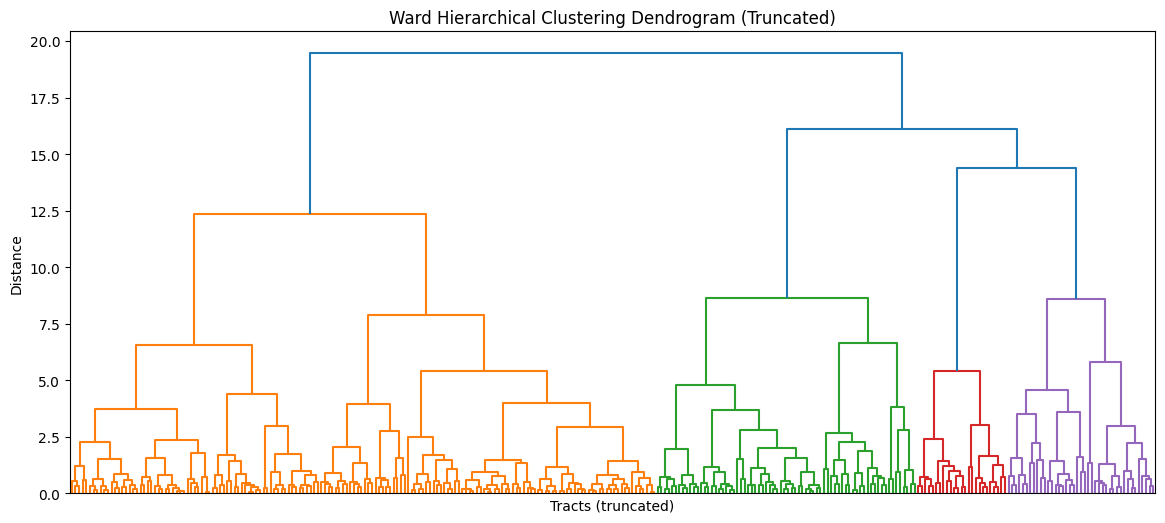

In [16]:
# Use the PCA scores for clustering
X = socioeconomic_tract_pca_scores[['PC1', 'PC2', 'PC3']].reset_index(drop=True)

# Standardize (good practice for hierarchical clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tract_ids = socioeconomic_tract_pca_scores['TRACT'].astype(str).reset_index(drop=True)

# Compute hierarchical clustering using Ward's method
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode='level',  # show only top hierarchical structure
    p=30,                   # number of leaf nodes to show
    no_labels=True,
)
plt.title("Ward Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Tracts (truncated)")
plt.ylabel("Distance")
plt.show()

In [17]:
labels = fcluster(Z, 3, criterion='maxclust')
socioeconomic_tract_pca_scores['hc_cluster'] = labels

cluster_profiles = (
    tract_socioeconomic_clean
    .merge(socioeconomic_tract_pca_scores[['TRACT','hc_cluster']], on='TRACT')
    .groupby('hc_cluster')[ses_vars]
    .mean()
)
print(cluster_profiles)

cluster_profiles.to_csv("data_processed/socioeconomic_pca_results_Charlotte/socioeconomics_cluster_profiles.csv", index=True)


            median_household_income  pct_below_50pct_poverty  pct_no_vehicle  \
hc_cluster                                                                     
1                         -0.042690                 0.020891       -0.444012   
2                          2.051636                -0.746857       -0.402884   
3                          0.585194                -0.317820        0.499546   

            pct_renters_cost_burdened  pct_over65  pct_with_disability  \
hc_cluster                                                               
1                            0.223335   -0.963815             0.364853   
2                           -0.084735   -0.311075             0.258324   
3                            0.635917   -0.221793            -0.870938   

            pct_nonwhite  
hc_cluster                
1               1.269262  
2              -0.513432  
3               0.184994  


Cluster 1 - this group has the lowest income and some poverty (not extreme though) most are cost burdened here and don't have access to a vehicles, there is also the highest percentage of disability and younger groups of people, this group is also more nonwhite

Cluster 2 - this group is wealthier, has access to vehicles, somewhat disabled, but also very white

Cluster 3 - Average household income, not really living in poverty, though they don't have access to vehicles so this might just be wealthier people who live in the city, somewhat not white

### Map PCs or SES variables directly

Because clusters are mild, mapping PC1–PC3 across NC may tell a richer story than clustering.

For example:

map 4: Ward clusters

In [18]:
tract_geo = gpd.read_file("data_raw/tl_2022_37_tract")
tract_geo['TRACT'] = tract_geo['GEOID']#.str[-6:]  # extract 6-digit tract code
tract_geo = tract_geo.to_crs(epsg=4326)

# Ensure TRACT columns are strings and zero-padded to 6 digits
#socioeconomic_tract_pca_scores['TRACT'] = socioeconomic_tract_pca_scores['TRACT'].astype(str).str.zfill(6)
#tract_geo['TRACT'] = tract_geo['TRACT'].astype(str).str.zfill(6)

# Merge GeoDataFrame with PCA+cluster data
gdf = tract_geo.merge(
    socioeconomic_tract_pca_scores[['TRACT','PC1','PC2','PC3','hc_cluster']],
    on='TRACT',
    how='left'
)

# Drop tracts missing PCA values (if any)
gdf = gdf.dropna(subset=['PC1','PC2','PC3'])

# Ensure GeoDataFrame is in WGS84 (plotly expects EPSG:4326)
gdf = gdf.to_crs(epsg=4326)

# Save an output GeoJSON for other apps / backup
gdf.to_file("data_processed/socioeconomic_pca_results_Charlotte/socioeconomic_tracts_with_pca_and_clusters.geojson", driver="GeoJSON")
print("Saved tracts_with_pca_and_clusters.geojson")

Saved tracts_with_pca_and_clusters.geojson


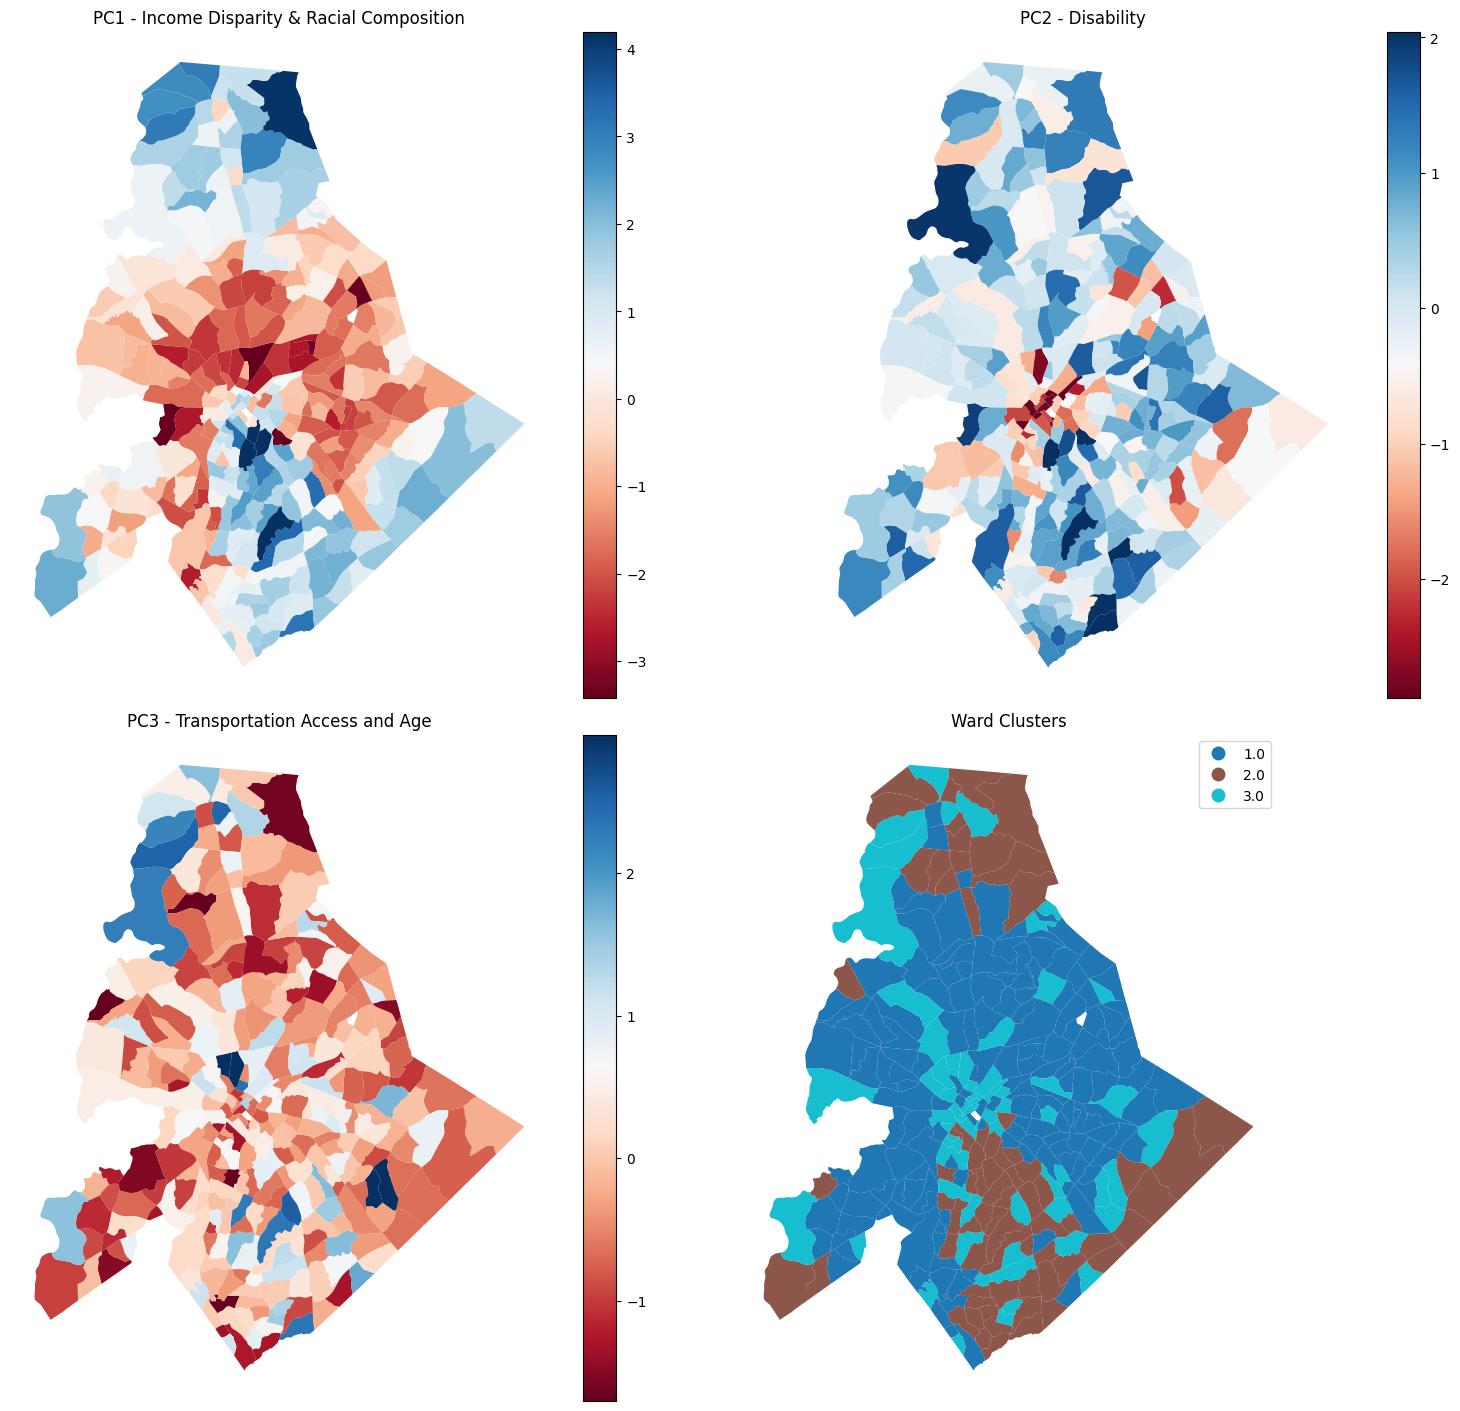

In [19]:
variables = ['PC1','PC2','PC3','hc_cluster']
titles = ['PC1 — Socioeconomic Advantage vs. Poverty', 'PC2 — Disability, Aging, and Racialized Vulnerability', 'PC3 — Housing Cost Pressure vs. Economic Security', 'Ward clusters']

fig, axes = plt.subplots(2, 2, figsize=(16, 14), constrained_layout=True)

variables = ['PC1', 'PC2', 'PC3', 'hc_cluster']
titles = [
    'PC1 - Income Disparity & Racial Composition',
    'PC2 - Disability',
    'PC3 - Transportation Access and Age',
    'Ward Clusters'
]

# axes is a 2x2 numpy array; flatten to 1D list of axes
axes = axes.ravel()

for i, var in enumerate(variables):
    ax = axes[i]  # <-- HERE IS THE FIX: ax is now a single Axes object

    if var == 'hc_cluster':
        # categorical map
        gdf.plot(
            column=var,
            ax=ax,
            categorical=True,
            legend=True,
            cmap='tab10',
            linewidth=0,
            edgecolor='none'
        )
    else:
        # continuous PCs with diverging colormap
        vmin = gdf[var].quantile(0.01)
        vmax = gdf[var].quantile(0.99)
        gdf.plot(
            column=var,
            ax=ax,
            cmap='RdBu',
            legend=True,
            vmin=vmin,
            vmax=vmax,
            linewidth=0,
            edgecolor='none'
        )

    ax.set_title(titles[i], fontsize=12)
    ax.set_axis_off()

plt.savefig(
    'data_processed/socioeconomic_pca_results_Charlotte/charlotte_pca_ward_maps.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Merge with outage + weather summaries (tract)

I have:
- tract_outages
- tract_weather

Which are summaries of outages and weather for each tract.

This will help compute:
- Outages per cluster
- Durations per cluster
- Weather exposure per cluster

In [31]:
tract_outages = pd.read_csv('data_processed/PCA_data/tract_outages.csv')
tract_weather = pd.read_csv('data_processed/PCA_data/tract_weather.csv')

# Ensure TRACT columns are strings and zero-padded
#socioeconomic_tract_pca_scores['TRACT'] = socioeconomic_tract_pca_scores['TRACT'].astype(str).str.zfill(6)
#tract_outages['TRACT'] = tract_outages['TRACT'].astype(str).str.zfill(6)
#tract_weather['TRACT'] = tract_weather['TRACT'].astype(str).str.zfill(6)

socioeconomic_tract_pca_scores['TRACT'] = socioeconomic_tract_pca_scores['TRACT'].astype(str)
tract_outages['TRACT'] = tract_outages['TRACT'].astype(str)
tract_weather['TRACT'] = tract_weather['TRACT'].astype(str)

#MERGE DATSETS
# Merge PCA/cluster -> outages -> weather (left join on PCA tracts)
df = socioeconomic_tract_pca_scores[['TRACT','PC1','PC2','PC3','hc_cluster']].merge(
    tract_outages, on='TRACT', how='left'
).merge(
    tract_weather, on='TRACT', how='left'
)

# Bring in population for rates
pops = tract_socioeconomic_clean[['TRACT','total_population']].copy()
pops['TRACT'] = pops['TRACT'].astype(str).str.zfill(6)
df = df.merge(pops, on='TRACT', how='left')

#DEFINING METRICS TO SUMMARIZE (from tract_outages and tract_weather)
outage_metrics = [
    'total_outages',
    'mean_duration_hours',
    'median_duration_hours',
    'max_duration_hours',
    'total_duration_hours',
    'mean_customers_affected',
    'max_customers_affected',
    'total_customers_affected',
    'total_customer_minutes_out',
    'pct_outages_in_summer',
    'pct_outages_in_winter'
]

weather_metrics = [
    'max_gust_during_outage_days',
    'mean_wind_on_outage_days',
    'total_precip_on_outage_days',
    'mean_soilmoist_on_outage_days',
    'outage_weather_day_count'
]

#keeping metrics that exist
metrics = [m for m in (outage_metrics + weather_metrics) if m in df.columns]

# Per-cluster summary table (mean, median, std, count)
agg_funcs = {m: ['mean','median','std','count'] for m in metrics}
cluster_summary = df.groupby('hc_cluster').agg(agg_funcs)

# flatten MultiIndex columns
cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
cluster_summary = cluster_summary.reset_index().sort_values('hc_cluster')

Note that length of tract_outages and tract_weather are the same, but shorter than socioeconomic_tract_pca_scores. Might be worth double checking because means some tracts might be missing weather data primarily.

In [32]:
# Per-cluster rates, outages per 1000 people, customer-minutes per capita
df['outages_per_1000'] = df['total_outages'] / df['total_population'] * 1000
df['customer_minutes_per_capita'] = df['total_customer_minutes_out'] / df['total_population']
per_cluster_rates = df.groupby('hc_cluster')[['outages_per_1000','customer_minutes_per_capita']].agg(['mean','median','std']).reset_index()

# STEP C — Identify outlier clusters

Define outliers as:

    • Tracts where outage frequency/duration is > 2 standard deviations above cluster mean
    • Tracts with high weather exposure but low outages (or vice versa)

In [33]:
# Flag per-tract outliers within each cluster (z-score within cluster)
# Compute z-scores within each hc_cluster for a small set of key metrics:
key_metrics = ['total_outages','total_duration_hours','total_customer_minutes_out','mean_duration_hours','max_gust_during_outage_days']
key_metrics = [m for m in key_metrics if m in df.columns]

# compute z-scores grouped by cluster
def z_within_group(group, cols):
    return group[cols].transform(lambda x: (x - x.mean()) / x.std(ddof=0))

zcols = [f"{m}_z_within_cluster" for m in key_metrics]
df[zcols] = z_within_group(df, key_metrics)

# Flag outliers: absolute z > 2 → unusual
for m, zcol in zip(key_metrics, zcols):
    df[f"{m}_is_outlier"] = df[zcol].abs() > 2

# Create an "outlier score" as sum of flags
outlier_flag_cols = [c for c in df.columns if c.endswith('_is_outlier')]
df['outlier_score'] = df[outlier_flag_cols].sum(axis=1)

# Top standout tracts by outlier_score, tiebreaker by max z magnitude
df['max_abs_z'] = df[zcols].abs().max(axis=1)
outlier_list = df.sort_values(['outlier_score','max_abs_z'], ascending=[False, False]).head(50)

Saved: data_processed/socioeconomic_pca_results_Charlotte/outlier_tracts_static_map_polygons_only.png


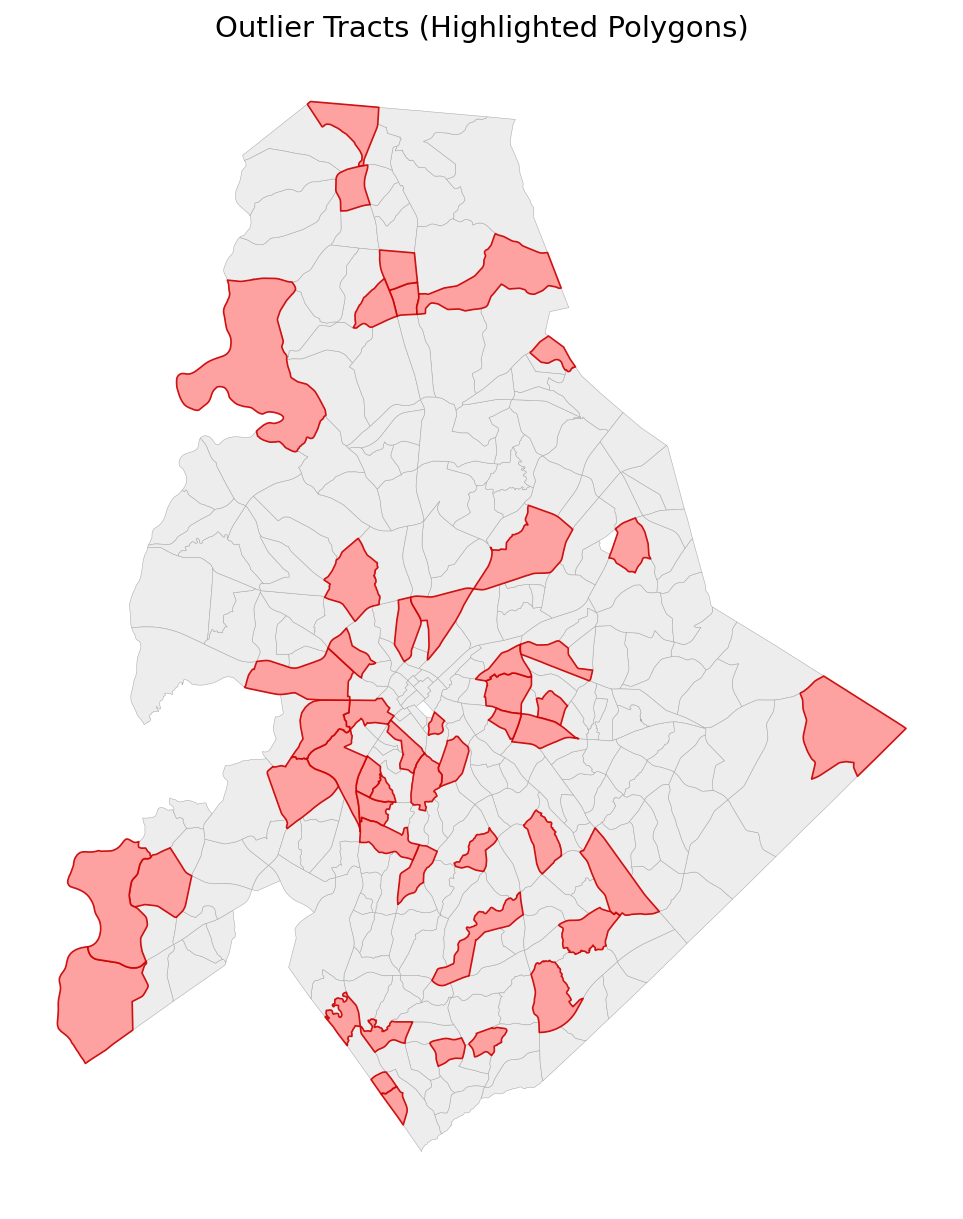

In [34]:
gdf['TRACT'] = gdf['TRACT'].astype(str).str.zfill(6)
outlier_df = outlier_list.copy()
outlier_df['TRACT'] = outlier_df['TRACT'].astype(str).str.zfill(6)

# Merge outlier flag into full GeoDataFrame
gdf_map = gdf.merge(
    outlier_df[['TRACT','outlier_score','max_abs_z']],
    on='TRACT',
    how='left'
)

# Outlier polygons only
outlier_gdf = gdf_map[gdf_map['outlier_score'].notna()].copy()

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=150)

# Plot all tracts in very light gray
gdf_map.plot(ax=ax, color='#EDEDED', edgecolor='#AAAAAA', linewidth=0.25)

# Highlight outlier polygons (NO centroids, NO dots)
outlier_gdf.plot(ax=ax,
                 facecolor='#ff9999',   # soft red fill
                 edgecolor='#cc0000',   # darker outline
                 linewidth=0.8,
                 alpha=0.9)

# Clean up
ax.set_axis_off()
ax.set_title("Outlier Tracts (Highlighted Polygons)", fontsize=14)

# Save to file
out_path = "data_processed/socioeconomic_pca_results_Charlotte/outlier_tracts_static_map_polygons_only.png"
plt.savefig(out_path, bbox_inches='tight', pad_inches=0.1)
print(f"Saved: {out_path}")

plt.show()

In [35]:
#SAVE RESULTS
cluster_summary.to_csv("data_processed/socioeconomic_pca_results_Charlotte/cluster_outage_weather_summary.csv", index=False)
df.to_csv("data_processed/socioeconomic_pca_results_Charlotte/tracts_with_clusters_outage_weather.csv", index=False)
outlier_list.to_csv("data_processed/socioeconomic_pca_results_Charlotte/top50_standout_tracts.csv", index=False)
print("Saved cluster_outage_weather_summary.csv, tracts_with_clusters_outage_weather.csv, top50_standout_tracts.csv")

Saved cluster_outage_weather_summary.csv, tracts_with_clusters_outage_weather.csv, top50_standout_tracts.csv


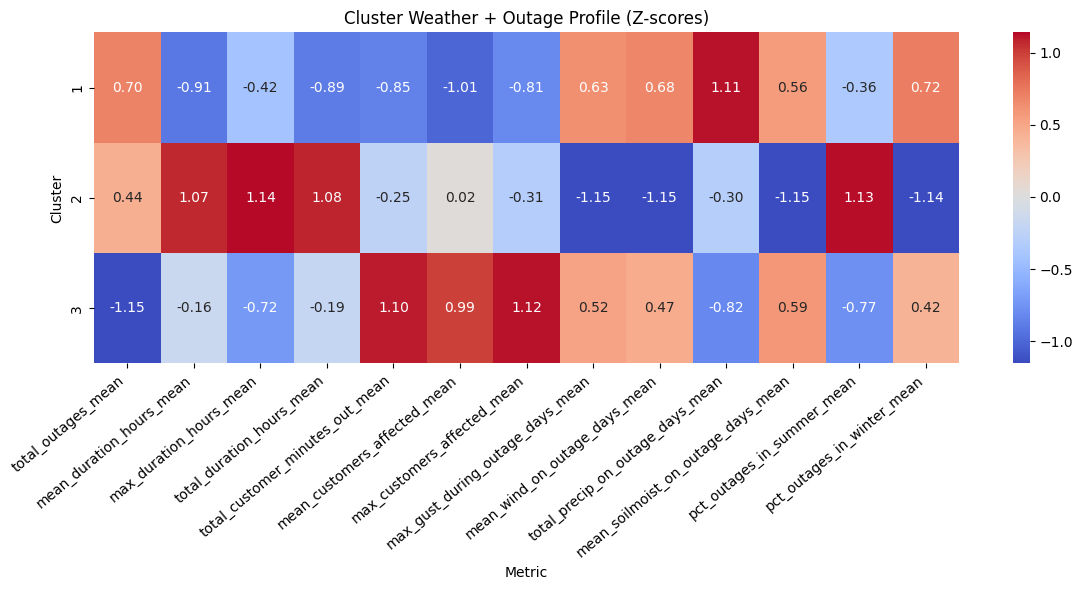

In [37]:
#image creating with the cluster summary

# Columns we want to use (as defined above)
cols = [
    'total_outages_mean',
    'mean_duration_hours_mean',
    'max_duration_hours_mean',
    'total_duration_hours_mean',
    'total_customer_minutes_out_mean',
    'mean_customers_affected_mean',
    'max_customers_affected_mean',
    'max_gust_during_outage_days_mean',
    'mean_wind_on_outage_days_mean',
    'total_precip_on_outage_days_mean',
    'mean_soilmoist_on_outage_days_mean',
    'pct_outages_in_summer_mean',
    'pct_outages_in_winter_mean'
]
#cluster-level z-scores (above/below average)
cluster_summary_std = cluster_summary.copy()
cluster_summary_std[cols] = cluster_summary_std[cols].apply(
    lambda x: (x - x.mean()) / x.std()
)

import seaborn as sns

heatmap_data = cluster_summary_std.set_index('hc_cluster')[cols]

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Cluster Weather + Outage Profile (Z-scores)")
plt.xlabel("Metric")
plt.ylabel("Cluster")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()

plt.savefig(
    'data_processed/socioeconomic_pca_results_Charlotte/cluster_weather_outage_profile.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()